This is a companion notebook for the book [Deep Learning with Python, Third Edition](TODO). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

In [1]:
#!pip install keras-nightly keras-hub-nightly --upgrade -q

In [2]:
import os
os.environ["KERAS_BACKEND"] = "jax"

### Getting the most our of your models

Blindly trying out different architecture configurations works well enough if you just
need something that works okay. In this section, we’ll go beyond “works okay” to “works
great and wins machine learning competitions” via a quick guide to a set of must-know
techniques for building state-of-the-art deep learning models.

#### Hyperparameter optimization

When building a deep learning model, you have to make many seemingly arbitrary
decisions: How many layers should you stack? How many units or filters should go in
each layer? Should you use relu as an activation, or a different function? Should you
use BatchNormalization after a given layer? How much dropout should you use? And
so on. These architecture-level parameters are called hyperparameters to distinguish
them from the parameters of a model, which are trained via backpropagation.

In practice, experienced machine learning engineers and researchers build intuition
over time as to what works and what doesn’t when it comes to these choices—they
develop hyperparameter-tuning skills. But there are no formal rules. If you want to get
to the very limit of what can be achieved on a given task, you can’t be content with such
arbitrary choices. Your initial decisions are almost always suboptimal, even if you have
very good intuition. You can refine your choices by tweaking them by hand and retraining
the model repeatedly—that’s what machine learning engineers and researchers
spend most of their time doing. But it shouldn’t be your job as a human to fiddle with
hyperparameters all day—that is better left to a machine.

Thus, you need to explore the space of possible decisions automatically and systematically
in a principled way. You need to search the architecture space and find the
best-performing ones empirically. That’s what the field of automatic hyperparameter
optimization is about: it’s an entire field of research, and an important one.
The process of optimizing hyperparameters typically looks like this:

1 Choose a set of hyperparameters (automatically).

2 Build the corresponding model.

3 Fit it to your training data, and measure performance on the validation data.

4 Choose the next set of hyperparameters to try (automatically).

5 Repeat.

6 Eventually, measure performance on your test data.

The key to this process is the algorithm that analyzes the relationship between validation
performance and various hyperparameter values to choose the next set of hyperparameters
to evaluate. Many different techniques are possible: Bayesian optimization,
genetic algorithms, simple random search, and so on.

Training the weights of a model is relatively easy: you compute a loss function on
a mini-batch of data and then use backpropagation to move the weights in the right
direction. Updating hyperparameters, on the other hand, presents unique challenges.
Consider that

¡ The hyperparameter space is typically made of discrete decisions and thus isn’t
continuous or differentiable. Hence, you typically can’t do gradient descent in
hyperparameter space. Instead, you must rely on gradient-free optimization
techniques, which, naturally, are far less efficient than gradient descent.

¡ Computing the feedback signal of this optimization process (does this set
of hyperparameters lead to a high-performing model on this task?) can be
extremely expensive: it requires creating and training a new model from scratch
on your dataset.

¡ The feedback signal may be noisy: if a training run performs 0.2% better, is that
because of a better model configuration or because you got lucky with the initial
weight values?

Thankfully, there’s a tool that makes hyperparameter tuning simpler: KerasTuner.

##### Using KerasTuner

The key idea that KerasTuner is built upon is to let you replace hardcoded hyperparameter
values, such as units=32, with a range of possible choices, such as
Int(name="units", min_value=16, max_value=64, step=16). The set of such choices in
a given model is called the search space of the hyperparameter tuning process.

To specify a search space, define a model-building function (see the next listing).
It takes an hp argument, from which you can sample hyperparameter ranges, and it
returns a compiled Keras model.

In [3]:
#!pip install keras-tuner -q

In [4]:
import keras
from keras import layers

def build_model(hp):
    units = hp.Int(name="units", min_value=16, max_value=64, step=16)
    model = keras.Sequential(
        [
            layers.Dense(units, activation="relu"),
            layers.Dense(10, activation="softmax"),
        ]
    )
    optimizer = hp.Choice(name="optimizer", values=["rmsprop", "adam"])  # different kinds of hyperparameters are vailable
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model  # function returns a compiled model

In [5]:
import keras_tuner as kt

class SimpleMLP(kt.HyperModel):
    def __init__(self, num_classes):    # Thanks to the object-oriented approach, we can configure model constants as constructor arguments (instead of hardcoding them in the model-building function).
        self.num_classes = num_classes

    def build(self, hp):    # The build method is identical to our prior build_model standalone function.
        units = hp.Int(name="units", min_value=16, max_value=64, step=16)
        model = keras.Sequential(
            [
                layers.Dense(units, activation="relu"),
                layers.Dense(self.num_classes, activation="softmax"),
            ]
        )
        optimizer = hp.Choice(name="optimizer", values=["rmsprop", "adam"])
        model.compile(
            optimizer=optimizer,
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"],
        )
        return model

hypermodel = SimpleMLP(num_classes=10)

The next step is to define a “tuner.” Schematically, you can think of a tuner as a for
loop, which will repeatedly

¡ Pick a set of hyperparameter values

¡ Call the model-building function with these values to create a model

¡ Train the model and record its metrics

KerasTuner has several built-in tuners available—RandomSearch, BayesianOptimization,
and Hyperband. Let’s try BayesianOptimization, a tuner that attempts to make smart
predictions for which new hyperparameter values are likely to perform best given the
outcome of previous choices:
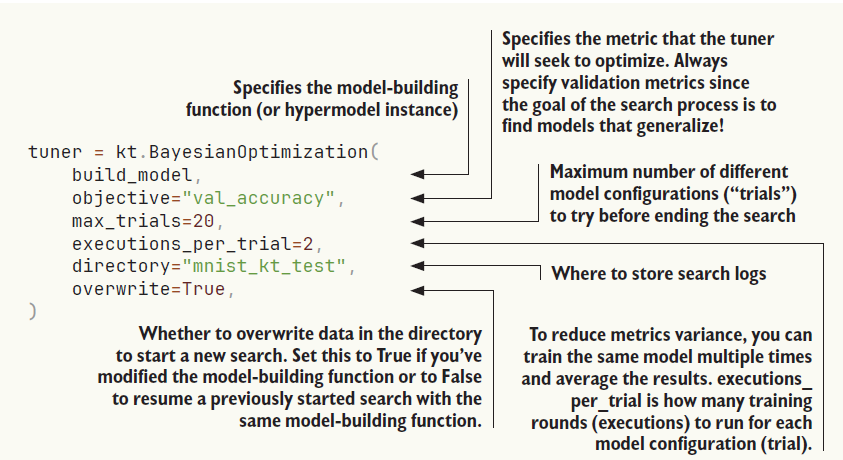

In [6]:
tuner = kt.BayesianOptimization(
    build_model,
    objective="val_accuracy",
    max_trials=20,
    executions_per_trial=2,
    directory="mnist_kt_test",
    overwrite=True,
)

You can display an overview of the search space via search_space_summary():

In [7]:
tuner.search_space_summary()

Search space summary
Default search space size: 2
units (Int)
{'default': None, 'conditions': [], 'min_value': 16, 'max_value': 64, 'step': 16, 'sampling': 'linear'}
optimizer (Choice)
{'default': 'rmsprop', 'conditions': [], 'values': ['rmsprop', 'adam'], 'ordered': False}


## Objective maximization and minimization

For built-in metrics (like accuracy, in our case), the direction of the metric (accuracy
should be maximized, but a loss should be minimized) is inferred by KerasTuner. However,
for a custom metric, you should specify it yourself, like this:

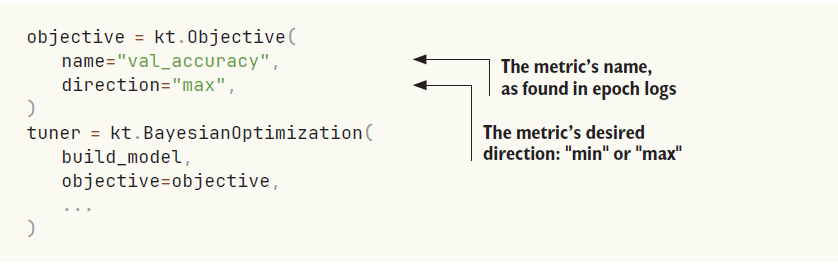

Finally, let’s launch the search. Don’t forget to pass validation data and make sure not
to use your test set as validation data—otherwise, you’d quickly start overfitting to your
test data, and you wouldn’t be able to trust your test metrics anymore:

In [8]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train = x_train.reshape((-1, 28 * 28)).astype("float32") / 255
x_test = x_test.reshape((-1, 28 * 28)).astype("float32") / 255
x_train_full = x_train[:]
y_train_full = y_train[:]
num_val_samples = 10000
x_train, x_val = x_train[:-num_val_samples], x_train[-num_val_samples:]
y_train, y_val = y_train[:-num_val_samples], y_train[-num_val_samples:]
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5),
]
tuner.search(    # This takes the same arguments as fit(), it simply passes them down to fit() for each new model.
    x_train,
    y_train,
    batch_size=128,
    epochs=100,   # uses large number of epochs since we don't know in advance how many we will need and uses early stopping callback to stop training
    validation_data=(x_val, y_val),
    callbacks=callbacks,
    verbose=2,
)

Trial 20 Complete [00h 00m 45s]
val_accuracy: 0.9750500023365021

Best val_accuracy So Far: 0.9754999876022339
Total elapsed time: 00h 12m 17s


The previous example will run in just a few minutes since we’re only looking at a few
possible choices and we’re training on MNIST. However, with a typical search space
and dataset, you’ll often find yourself letting the hyperparameter search run overnight
or even over several days. If your search process crashes, you can always restart it—just
specify overwrite=False in the tuner so that it can resume from the trial logs stored
on disk.

Once the search is complete, you can query the best hyperparameter configurations,
which you can use to create high-performing models that you can then retrain.

In [9]:
top_n = 4
best_hps = tuner.get_best_hyperparameters(top_n)

Usually, when retraining these models, you may want to include the validation data
as part of the training data since you won’t be making any further hyperparameter
changes, and thus you will no longer be evaluating performance on the validation data.
In our example, we’d train these final models on the totality of the original MNIST
training data, without reserving a validation set.

Before we can train on the full training data, though, there’s one last parameter
we need to settle: the optimal number of epochs to train for. Typically, you’ll want to
train the new models for longer than you did during the search: using an aggressive
patience value in the EarlyStopping callback saves time during the search, but may lead
to underfitted models. Just use the validation set to find the best epoch:

In [10]:
def get_best_epoch(hp):
    model = build_model(hp)
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", mode="min", patience=10   # large patience value
        )
    ]
    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=100,
        batch_size=128,
        callbacks=callbacks,
    )
    val_loss_per_epoch = history.history["val_loss"]
    best_epoch = val_loss_per_epoch.index(min(val_loss_per_epoch)) + 1
    print(f"Best epoch: {best_epoch}")
    return best_epoch

And finally, train on the full dataset for just a bit longer than this epoch count, since
you’re training on more data—20% more, in this case:

In [11]:
def get_best_trained_model(hp):
    best_epoch = get_best_epoch(hp)
    model = build_model(hp)
    model.fit(
        x_train_full, y_train_full, batch_size=128, epochs=int(best_epoch * 1.2)
    )
    return model

best_models = []
for hp in best_hps:
    model = get_best_trained_model(hp)
    model.evaluate(x_test, y_test)
    best_models.append(model)

Epoch 1/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7801 - loss: 0.7813 - val_accuracy: 0.9318 - val_loss: 0.2403
Epoch 2/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9297 - loss: 0.2465 - val_accuracy: 0.9481 - val_loss: 0.1868
Epoch 3/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9477 - loss: 0.1833 - val_accuracy: 0.9558 - val_loss: 0.1551
Epoch 4/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9582 - loss: 0.1471 - val_accuracy: 0.9591 - val_loss: 0.1403
Epoch 5/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9658 - loss: 0.1198 - val_accuracy: 0.9623 - val_loss: 0.1255
Epoch 6/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9696 - loss: 0.1048 - val_accuracy: 0.9653 - val_loss: 0.1169
Epoch 7/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9754 - loss: 0.0879 - val_accuracy: 0.9676 - val_loss: 0.1067
Epoch 8/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9768 - loss: 0.0806 - val_accu

If you’re not worried about slightly underperforming, there’s a shortcut you can take:
just use the tuner to reload the top-performing models with the best weights saved
during the hyperparameter search, without retraining new models from scratch:

In [12]:
best_models = tuner.get_best_models(top_n)

c:\Users\donda\anaconda3\envs\tensorflow\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


NOTE One important issue to keep in mind when doing automatic hyperparameter
optimization at scale is validation-set overfitting. Because you’re
updating hyperparameters based on a signal that is computed using your validation
data, you’re effectively training them on the validation data, and thus,
they will quickly overfit to the validation data. Always keep this in mind.

##### The art of crafting the right search space

Overall, hyperparameter optimization is a powerful technique that is an absolute
requirement to get to state-of-the-art models on any task or to win machine learning
competitions. Think about it: once upon a time, people handcrafted the features that
went into shallow machine learning models. That was very suboptimal. Now deep
learning automates the task of hierarchical feature engineering—features are learned
using a feedback signal, not hand-tuned, and that’s the way it should be. In the same
way, you shouldn’t handcraft your model architectures; you should optimize them in a
principled way.

However, doing hyperparameter tuning is not a replacement for being familiar with
model architecture best practices: search spaces grow combinatorially with the number
of choices, so it would be far too expensive to turn everything into a hyperparameter
and let the tuner sort it out. You need to be smart about designing the right search
space. Hyperparameter tuning is automation, not magic: you use it to automate experiments
that you would otherwise have run by hand, but you still need to handpick experiment
configurations that have the potential to yield good metrics.

The good news: by using hyperparameter tuning, the configuration decisions you
have to make graduate from micro-decisions (What number of units do I pick for
this layer?) to higher-level architecture decisions (Should I use residual connections
throughout this model?). And while micro-decisions are specific to a certain model and a certain dataset, higher-level decisions generalize better across different tasks and
datasets: for instance, pretty much every image classification problem can be solved via
the same sort of search space template.

Following this logic, KerasTuner attempts to provide premade search spaces that are
relevant to broad categories of problems—such as image classification. Just add data, run
the search, and get a pretty good model. You can try the hypermodels kt.applications
.HyperXception and kt.applications.HyperResNet, which are effectively tunable
versions of Keras Applications models.

##### The future of hyperparameter tuning: automated machine learning

#### Model ensembling

Another powerful technique for obtaining the best possible results on a task is model
ensembling. Ensembling consists of pooling together the predictions of a set of different
models to produce better predictions. If you look at machine learning competitions—
in particular, on Kaggle—you’ll see that the winners use very large ensembles of models
that inevitably beat any single model, no matter how good.

Ensembling relies on the assumption that different well-performing models trained
independently are likely to be good for different reasons: each model looks at slightly
different aspects of the data to make its predictions, getting part of the “truth” but not
all of it. You may be familiar with the ancient parable of the blind men and the elephant:
a group of blind men come across an elephant for the first time and try to understand
what the elephant is by touching it. Each man touches a different part of the elephant’s
body—just one part, such as the trunk or a leg. Then the men describe to each other
what an elephant is: “It’s like a snake,” “Like a pillar or a tree,” and so on. The blind
men are essentially machine learning models trying to understand the manifold of the
training data, each from its own perspective, using its own assumptions (provided by
the unique architecture of the model and the unique random weight initialization).

Each of them gets part of the truth of the data, but not the whole truth. By pooling their
perspectives together, you can get a far more accurate description of the data. The elephant
is a combination of parts: no single blind man gets it quite right, but interviewed
together, they can tell a fairly accurate story.

Let’s use classification as an example. The easiest way to pool the predictions of a
set of classifiers (to ensemble the classifiers) is to average their predictions at inference
time:
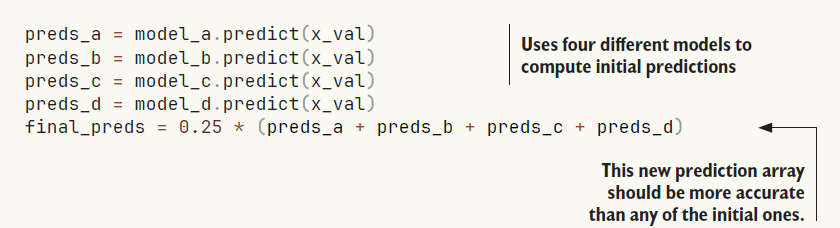

However, this will work only if the classifiers are more or less equally good. If one of
them is significantly worse than the others, the final predictions may not be as good as
the best classifier of the group.

A smarter way to ensemble classifiers is to do a weighted average, where the weights
are learned on the validation data—typically, the better classifiers are given a higher
weight, and the worse classifiers are given a lower weight. To search for a good set of
ensembling weights, you can use random search or a simple optimization algorithm,
such as the Nelder-Mead algorithm:

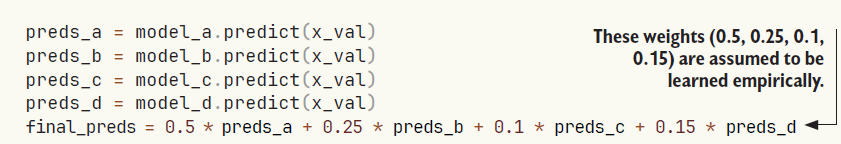

There are many possible variants: you can do an average of an exponential of the predictions,
for instance. In general, a simple weighted average with weights optimized on
the validation data provides a very strong baseline.

The key to making ensembling work is the diversity of the set of classifiers. Diversity
is strength. If all the blind men only touched the elephant’s trunk, they would agree
that elephants are like snakes, and they would forever stay ignorant of the truth of the
elephant. Diversity is what makes ensembling work. In machine learning terms, if all of
your models are biased in the same way, then your ensemble will retain this same bias.
If your models are biased in different ways, the biases will cancel each other out, and the
ensemble will be more robust and more accurate.

For this reason, you should ensemble models that are as good as possible while being as
different as possible. This typically means using very different architectures or even different
brands of machine learning approaches. One thing that is largely not worth doing
is ensembling the same network trained several times independently, from different
random initializations. If the only difference between your models is their random initialization
and the order in which they were exposed to the training data, then your
ensemble will be low in diversity and will provide only a tiny improvement over any
single model.

One thing I have found to work well in practice—but that doesn’t generalize to every
problem domain—is the use of an ensemble of tree-based methods (such as random
forests or gradient-boosted trees) and deep neural networks. In 2014, Andrei Kolev and I
took fourth place in the Higgs Boson decay detection challenge on Kaggle (www.kaggle
.com/c/higgs-boson) using an ensemble of various tree models and deep neural networks.
Remarkably, one of the models in the ensemble originated from a different
method than the others (it was a regularized greedy forest) and had a significantly worse
score than the others. Unsurprisingly, it was assigned a small weight in the ensemble. But
to our surprise, it turned out to improve the overall ensemble by a large factor because it was so different from every other model: it provided information that the other models
didn’t have access to. That’s precisely the point of ensembling. It’s not so much about
how good your best model is; it’s about the diversity of your set of candidate models.


### Scaling up model training with multiple devices

Recall the “loop of progress” concept we
introduced in chapter 7: the quality of your
ideas is a function of how many refinement
cycles they’ve been through (figure 18.1).
And the speed at which you can iterate on
an idea is a function of how fast you can set
up an experiment, how fast you can run that
experiment, and, finally, how well you can
analyze the resulting data.

As you develop your expertise in the
Keras API, how fast you can code up your
deep learning experiments will cease to be the bottleneck of this progress cycle. The
next bottleneck will become the speed at which you can train your models. Fast training
infrastructure means that you can get your results back in 10 or 15 minutes and, hence,
that you can go through dozens of iterations every day. Faster training directly improves
the quality of your deep learning solutions.

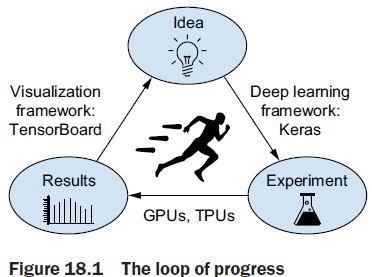

#### Multi-GPU training

While GPUs are getting more powerful every year, deep learning models are also getting
increasingly larger, requiring ever more computational resources. Training on a
single GPU puts a hard bound on how fast you can move. The solution? You could simply
add more GPUs and start doing multi-GPU distributed training.

There are two ways to distribute computation across multiple devices: data parallelism
and model parallelism.

With data parallelism, a single model gets replicated on multiple devices or multiple
machines. Each of the model replicas processes different batches of data, and then they
merge their results.

With model parallelism, different parts of a single model run on different devices,
processing a single batch of data together at the same time. This works best with models
that have a naturally parallel architecture, such as models that feature multiple
branches. In practice, model parallelism is only used in the case of models that are too
large to fit on any single device: it isn’t used as a way to speed up training of regular
models but as a way to train larger models.

Then, of course, you can also mix both data parallelism and model parallelism: a
single model can be split across multiple devices (e.g., 4), and that split model can be replicated across multiple groups of devices (e.g., twice, for a total of 2 * 4 = 8 devices
used).

##### Data parallelism: replicate your model on each GPU

Data parallelism is the most common form of distributed training. It operates on a
simple principle: divide and conquer. Each GPU receives a copy of the entire model,
called a replica. Incoming batches of data are split into N sub-batches, which are processed
by one model replica each, in parallel. This is why it’s called data parallelism:

different samples (data points) are processed in parallel. For instance, with two GPUs,
a batch of size 128 would be split into two sub-batches of size 64, which would be processed
by two model replicas. Then

¡ In inference—We would retrieve the predictions for each sub-batch and concatenate
them to obtain the predictions for the full batch.

¡ In training—We would retrieve the gradients for each sub-batch, average them,
and update all model replicas based on the gradient average. The state of the
model would then be the same as if you had trained it on the full batch of 128
samples. This is called synchronous training, since all replicas are kept in sync—
their weights have the same value at all times. Nonsynchronous alternatives exist,
but they are less efficient and aren’t used anymore in practice.

Data parallelism is a simple and highly scalable way to train your models faster. If you
get more devices, just increase your batch size, and your training throughput increases
accordingly. It has one limitation, though: it requires your model to be able to fit into
one of your devices. However, it is now common to train foundation models that have
tens of billions of parameters, which wouldn’t fit on any single GPU.

##### Model parallelism: split your model across multiple GPUs

That’s where model parallelism comes in. While data parallelism works by splitting your
batches of data into sub-batches and processing the sub-batches in parallel, model parallelism
works by splitting your model into submodels and running each one on a different
device—in parallel. For instance, consider the following model.

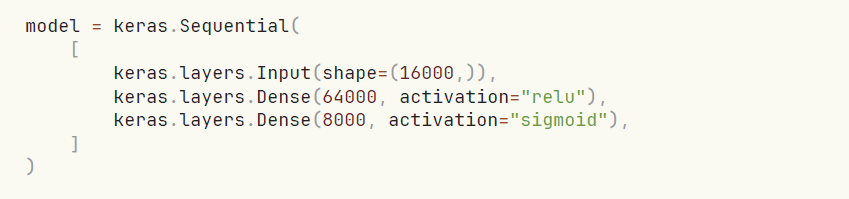

Each sample has 16,000 features and gets classified into 8,000 potentially overlapping
categories by two Dense layers. Those are large layers—the first one has about 1 billion parameters, and the last one has about 512 million parameters. If you’re working
with two small devices, you won’t be able to use data parallelism, since you can’t fit
the model on a single device. What you can do is split a single instance of the model
across multiple devices. This is often called sharding or partitioning a model. There
are two main ways to split a model across devices: horizontal partitioning and vertical
partitioning.

In horizontal partitioning, each device processes different layers of the model. For
example, in the previous model, one GPU would handle the first Dense layer, and the
other one would handle the second Dense layer. The main drawback of this approach
is that it can introduce communication overhead. For example, the output of the first
layer needs to be copied to the second device before it can be processed by the second
layer. This can become a bottleneck, especially if the output of the first layer is large—
you’d risk keeping your GPUs idle.

In vertical partitioning, each layer is split across all available devices. Since layers are
usually implemented in terms of matmul or convolution operations, which are highly
parallelizable, this strategy is easy to implement in practice and is almost always the best
fit for large models. For example, in the previous model, you could split the kernel and
bias of the first Dense layer into two halves so that each device only receives a kernel of
shape (16000, 32000) (split along its last axis) and a bias of shape (32000,). You’d compute
matmul(inputs, kernel) + bias with this half-kernel and half-bias for each device,
and you’d merge the two outputs by concatenating them like this:

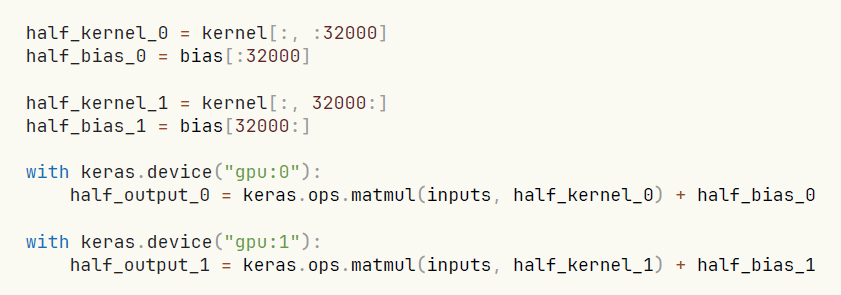

In reality, you will want to mix data parallelism and model parallelism. You will split
your model across, say, four devices, and you will replicate that split model across multiple
groups of two devices—let’s say two—each processing one sub-batch of data in
parallel. You will then have two replicas, each running on four devices, for a total of
eight devices used.

##### Distributed training in practice

Now let’s see how to implement these concepts in practice. We will only cover the JAX
backend, as it is the most performant and most scalable of the various Keras backends,
by a mile. If you’re doing any kind of large-scale distributed training and you aren’t using JAX, you’re making a mistake—
and wasting your dollars burning way
more compute than you actually need.

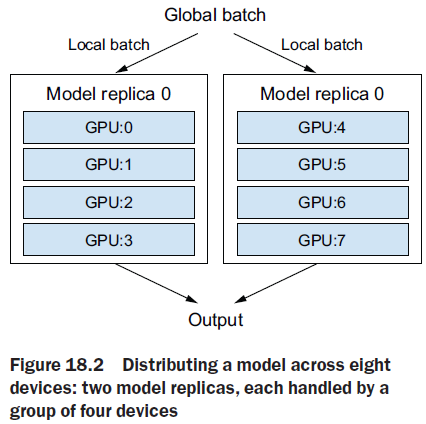

###### Getting your hands on two or more GPUs

First, you need to get access to several
GPUs. As of now, Google Colab only
lets you use a single GPU, so you will
need to do one of two things:

¡ Acquire two to eight GPUs, mount
them on a single machine (it will
require a beefy power supply),
and install CUDA drivers, cuDNN,
etc. For most people, this isn’t the
best option.

¡ Rent a multi-GPU virtual machine
(VM) on Google Cloud, Azure, or AWS. You’ll be able to use VM images with pre-installed
drivers and software, and you’ll have very little setup overhead. This is
likely the best option for anyone who isn’t training models 24/7.

We won’t cover the details of how to spin up multi-GPU cloud VMs because such
instructions would be relatively short-lived, and this information is readily available
online.

###### Using data parallelism with JAX

Using data parallelism with Keras and JAX is very simple: before building your model,
just add the following line of code:

keras.distribution.set_distribution(keras.distribution.DataParallel())

That’s it.

If you want more granular control, you can specify which devices you want to use. You
can list available devices via

keras.distribution.list_devices()

It will return a list of strings—the names of your devices, such as "gpu:0", "gpu:1", and
so on. You can then pass these to the DataParallel constructor:

keras.distribution.set_distribution(
keras.distribution.DataParallel(["gpu:0", "gpu:1"])
)

In an ideal world, training on N GPUs would result in a speedup of factor N. In practice,
however, distribution introduces some overhead—in particular, merging the weight
deltas originating from different devices takes some time. The effective speedup you
get is a function of the number of GPUs used:

¡ With two GPUs, the speedup stays close to 2×.

¡ With four, the speedup is around 3.8×.

¡ With eight, it’s around 7.3×.

This assumes that you’re using a large-enough global batch size to keep each GPU utilized
at full capacity. If your batch size is too small, the local batch size won’t be enough
to keep your GPUs busy.

###### Using model parallelism with JAX

Keras also provides powerful tools for fully customizing how you want to do distributed
training, including model parallel training and any mixture of data parallel and model
parallel training you can imagine.

#### TPU training

Beyond just GPUs, there is generally a trend in the deep learning world toward moving
workflows to increasingly specialized hardware designed specifically for deep learning
workflows; such single-purpose chips are known as ASICs (application-specific integrated
circuits). Various companies big and small are working on new chips, but today
the most prominent effort along these lines is Google’s Tensor Processing Unit (TPU),
which is available on Google Cloud and via Google Colab.

Training on TPU does involve jumping through some hoops. But it’s worth the extra
work: TPUs are really, really fast. Training on a TPU v2 (available on Colab) will typically
be 15× faster than training a NVIDIA P100 GPU. For most models, TPU training
ends up being 3× more cost-effective than GPU training on average.

You can actually use TPU v2 for free in Colab. In the Colab menu, under the Runtime
tab, in the Change Runtime Type option, you’ll notice that you have access to a TPU runtime in addition to the GPU runtime. For more serious training runs, Google
Cloud also makes available TPU v3 through v5, which are even faster.
When running Keras code with the JAX backend on a TPU-enabled notebook,
you don’t need anything more than calling keras.distribution.set_distribution
(distribution) with a DataParallel or ModelParallel distribution instance to start
using your TPU cores. Make sure to call it before creating your model!

NOTE Because TPUs can process batches of data extremely quickly, the speed
at which you can read data from Google Cloud Storage (GCS) can easily
become a bottleneck. If your dataset is small enough, you should keep it in the
memory of the virtual machine. You can do so by calling dataset.cache() on
your tf.data.Dataset instance. That way, the data will only be read from GCS
once.

##### Leveraging step fusing to improve TPU utilization

Because a TPU has a lot of compute power available, you need to train with very large
batches to keep the TPU cores busy. For small models, the batch size required can get
extraordinarily large—upward of 10,000 samples per batch. When working with enormous
batches, you should make sure to increase your optimizer learning rate accordingly:
you’re going to be making fewer updates to your weights, but each update will be
more accurate (since the gradients are computed using more data points); hence, you
should move the weights by a greater magnitude with each update.

There is, however, a simple trick you can use to keep reasonably sized batches while
maintaining full TPU utilization: step fusing. The idea is to run multiple steps of training
during each TPU execution step. Basically, do more work in between two roundtrips
from the virtual machine memory to the TPU. To do this, simply specify the steps_per_
execution argument in compile()—for instance, steps_per_execution=8 to run eight
steps of training during each TPU execution. For small models that are underutilizing
the TPU, this can result in a dramatic speedup:

model.compile(..., steps_per_execution=8)

### Speeding up training and inference with lower-precision computation

What if I told you there’s a simple technique you could use to speed up training and
inference of almost any model by up to 2×, basically for free? It seems too good to be
true, and yet, such a trick does exist. To understand how it works, first, we need to take
a look at the notion of “precision” in computer science.

##### Understanding floating-point precision

Precision is to numbers what resolution is to images. Because computers can only process
1s and 0s, any number seen by a computer has to be encoded as a binary string.

For instance, you may be familiar with uint8 integers, which are integers encoded on
eight bits: 00000000 represents 0 in uint8, and 11111111 represents 255. To represent
integers beyond 255, you’d need to add more bits—eight isn’t enough. Most integers
are stored on 32 bits, with which we can represent signed integers ranging from
−2147483648 to 2147483647.

Floating-point numbers are the same. In mathematics, real numbers form a continuous
axis: there’s an infinite number of points in between any two numbers. You can
always zoom in on the axis of reals. In computer science, this isn’t true: there’s only a
finite number of intermediate points between 3 and 4, for instance. How many? Well, it
depends on the precision you’re working with: the number of bits you’re using to store a
number. You can only zoom up to a certain resolution.

There are three levels of precision you’d typically use:

¡ Half precision, or float16, where numbers are stored on 16 bits

¡ Single precision, or float32, where numbers are stored on 32 bits

¡ Double precision, or float64, where numbers are stored on 64 bits

You could even go up to float8, as you’ll see in a bit.

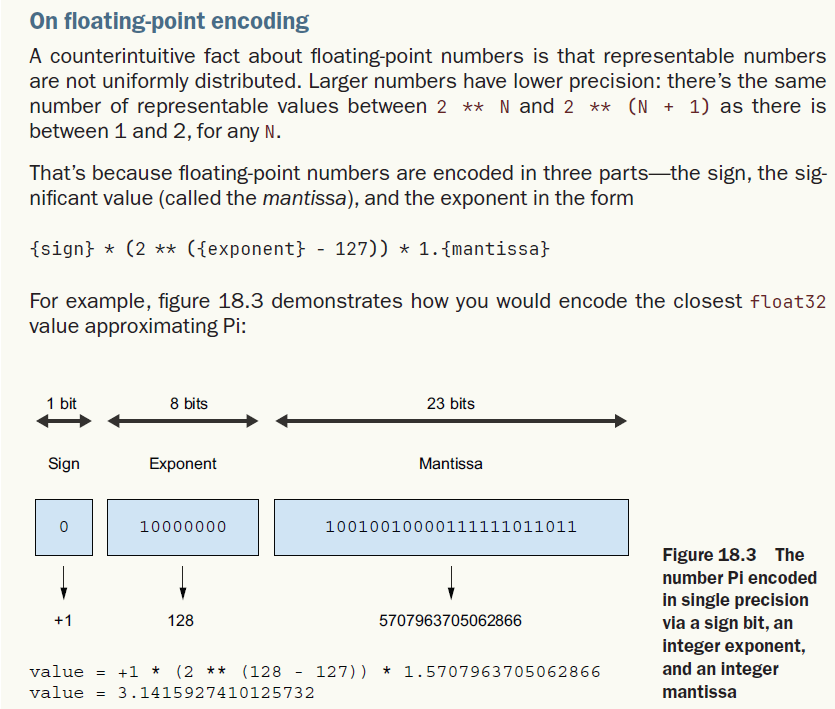
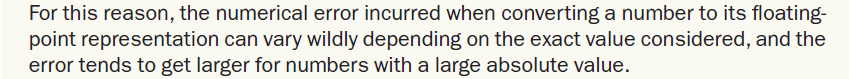

The way to think about the resolution of floating-point numbers is in terms of the
smallest distance between two arbitrary numbers that you’ll be able to safely process.
In single precision, that’s around 1e-7. In double precision, that’s around 1e-16. And in
half precision, it’s only 1e-3.

##### Float16 inference

Every model you’ve seen in this book so far has used single-precision numbers: it stored
its state as float32 weight variables and ran its computations on float32 inputs. That’s
enough precision to run the forward and backwards pass of a model without losing
any information—in particular when it comes to small gradient updates (recall that
the typically learning rate is 1e-3, and it’s pretty common to see weight updates on the
order of 1e-6).

Modern GPUs and TPUs feature specialized hardware that can run 16-bit operations
much faster and using less memory than equivalent 32-bit operations. By using
these lower-precision operations whenever possible, you can speed up training on those
devices by a significant factor. You can set the default floating point precision to float16
in Keras via 

import keras

keras.config.set_dtype_policy("float16")

Note that this should be done before you define your model. Doing this will net you
a nice speedup for model inference, for instance, via model.predict(). You should
expect a nearly 2× speed boost on GPU and TPU.

There’s also an alternative to float16 that works better on some devices, in particular
TPUs: bfloat16. bfloat16 is also a 16-bit precision floating-point type, but it differs
from float16 in its structure: it uses 8 exponent bits instead of 5, and 7 mantissa bits
instead of 10 (see table 18.1). This means it can cover a much wider range of values,
but it has a lower “resolution” over this range. Some devices are better optimized for
bfloat16 compared to float16, so it can be a good idea to try both before settling for
the option that turns out to be the fastest.

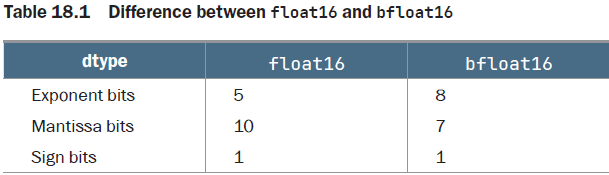

##### Mixed-precision training

Setting your default float precision to 16 bits is a great way to speed up inference. Now,
when it comes to training, there’s a significant complication. The gradient descent
process wouldn’t run smoothly in float16 or bfloa16, since we couldn’t represent
small gradient updates of around 1e-5 or 1e-6, which are quite common.

You can, however, use a hybrid approach: that’s what mixed-precision training is about.
The idea is to use 16-bit computation in places where precision isn’t an issue, while
working with 32-bit values in other places to maintain numerical stability—in particular,
when handling gradients and variable updates. By maintaining the precision-sensitive
parts of the model in full precision, you can get most of the speed benefits of 16-bit computation
without meaningfully impacting model quality.

You can turn on mixed precision like this:

import keras

keras.config.set_dtype_policy("mixed_float16")

Typically, most of the forward pass of the model will be done in float16 (with the
exception of numerically unstable operations like softmax), while the weights of the
model will be stored and updated in float32. Your float16 gradients will be cast to
float32 before updating the float32 variables.

Keras layers have a variable_dtype and a compute_dtype attribute. By default, both of
these are set to float32. When you turn on mixed precision, the compute_dtype of most
layers switches to float16. As a result, those layer will cast their inputs to float16 and
will perform their computation in float16 (using half-precision copies of the weights).
However, since their variable_dtype is still float32, their weights will be able to receive
accurate float32 updates from the optimizer, as opposed to half-precision updates.

Some operations may be numerically unstable in float16 (in particular, softmax and
crossentropy). If you need to opt out of mixed precision for a specific layer, just pass the
argument dtype="float32" to the constructor of this layer.

##### Using loss scaling with mixed precision

During training, gradients can become very small. When using mixed precision, your
gradients remain in float16 (same as the forward pass). As a result, the limited range of representable numbers can cause small gradients to be rounded down to zero. This
prevents the model from learning effectively.

Gradient values are proportional to the loss value, so to encourage gradients to be
larger, a simple trick is to multiply the loss by a large scalar factor. Your gradients will
then be much less likely to get rounded to zero.

Keras makes this easy. If you want to use a fixed loss scaling factor, you can simply pass
a loss_scale_factor argument to your optimizer like this:

optimizer = keras.optimizers.Adam(learning_rate=1e-3, loss_scale_factor=10)

If you would like for the optimizer to automatically figure out the right scaling factor,
you can also use the LossScaleOptimizer wrapper:

optimizer = keras.optimizers.LossScaleOptimizer(
keras.optimizers.Adam(learning_rate=1e-3)
)

Using LossScaleOptimizer is usually your best option: the right scaling value can
change over the course of training!

##### Beyond mixed precision: float8 training

If running your forward pass in 16-bit precision yields such neat performance benefits,
you might want to ask: Could we go even lower? What about 8-bit precision? Four bits,
maybe? Two bits? The answer is, it’s complicated.

Mixed precision training using float16 in the forward pass is that last level of precision
that “just works”—float16 precision has enough bits to represent all intermediate
tensors (except for gradient updates, which is why we use float32 for those). This is no
longer true if you go down to float8 precision: you are simply losing too much information.
It is still possible to use float8 in some computations, but this requires you to
make considerable modifications to your forward pass. You will not be able to simply set
your compute_dtype to float8 and run.

The Keras framework provides a built-in implementation for float8 training.
Because it specifically targets Transformer use cases, it only covers a restricted set of
layers: Dense, EinsumDense (the version of Dense that is used by the MultiHeadAttention
layer), and Embedding layers. The way it works is not simple—it keeps track of past activation
values to rescale activations at each step so as to utilize the full range of values
representable in float8. It also needs to override part of the backward pass to do the
same with gradient values.

Importantly, this added overhead has a computational cost. If your model is too small
or if your GPU isn’t powerful enough, that cost will exceed the benefits of doing certain
operations in float8, and you will see a slowdown instead of a speedup. float8 training is only viable for very large models (typically over 5B parameters) and large, recent
GPUs such as the NVDIA H100. float8 is rarely used in practice, except in foundation
model training runs.

#### Faster inference with quantization

Running inference in float16—or even float8—will result in a nice speedup for your
models. But there’s also another trick you can use: int8 quantization. The big idea is to
take an already trained model with weights in float32 and convert these weights to a
lower-precision dtype (typically int8) while preserving the numerical correctness of
the forward pass as much as possible.

If you want to implement quantization from scratch, the math is simple: the general
idea is to scale all matmul input tensors by a certain factor so that their coefficients fit in
the range representable with int8, which is [-127, 127]—a total of 256 possible values.
After scaling the inputs, you cast them to int8 and perform the matmul operation in
int8 precision, which should be quite a bit faster than float16. Finally, you cast the output
back to float32, and you divide it by the product of the input scaling factors. Since
matmul is a linear operation, this final unscaling cancels out the initial scaling, and you
should get the same output as if you used the original values—any loss of accuracy only
comes from the value rounding that happens when you cast the inputs to int8.

Let’s make this concrete with an example. Let’s say you want to perform matmul(x,
kernel), with the following values:

In [13]:
from keras import ops

x = ops.array([[0.1, 0.9], [1.2, -0.8]])
kernel = ops.array([[-0.1, -2.2], [1.1, 0.7]])

If you were to naively cast these values to int8 without scaling first, that would be very
destructive—for instance, your x would become [[0, 0], [1, 0]]. So let’s apply the
“abs-max” scaling scheme, which spreads out the values of each tensor across the
[-127, 127] range:

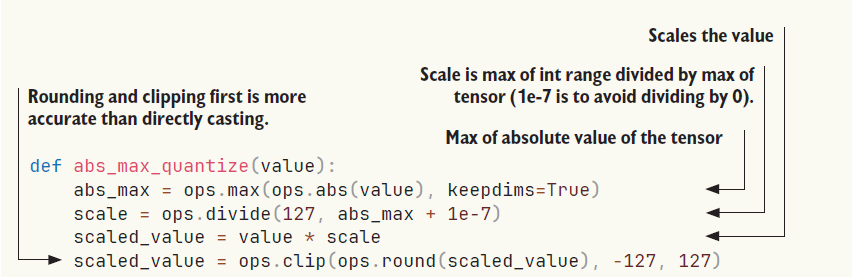

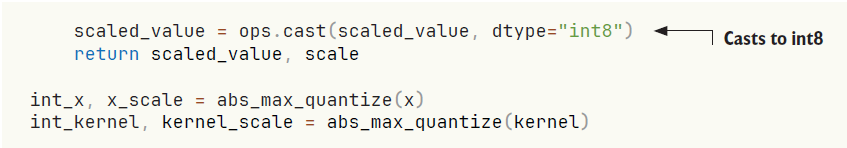

In [14]:
def abs_max_quantize(value):
    abs_max = ops.max(ops.abs(value), keepdims=True)
    scale = ops.divide(127, abs_max + 1e-7)
    scaled_value = value * scale
    scaled_value = ops.clip(ops.round(scaled_value), -127, 127)
    scaled_value = ops.cast(scaled_value, dtype="int8")
    return scaled_value, scale

int_x, x_scale = abs_max_quantize(x)
int_kernel, kernel_scale = abs_max_quantize(kernel)

Now we can perform a faster matmul and unscale the output:

In [15]:
int_y = ops.matmul(int_x, int_kernel)
y = ops.cast(int_y, dtype="float32") / (x_scale * kernel_scale)

How accurate is it? Let’s compare our y with the output of the float32 matmul:

In [16]:
y

Array([[ 0.9843736,  0.3933239],
       [-1.0151455, -3.1965137]], dtype=float32)

In [17]:
ops.matmul(x, kernel)

Array([[ 0.98      ,  0.40999997],
       [-1.        , -3.2       ]], dtype=float32)

Pretty accurate! For a large matmul, doing this will save you a lot of compute, since int8
computation can be considerably faster than even float16 computation, and you only
had to add fairly fast elementwise ops to the computation graphs—abs, max, clip, cast,
divide, multiply.

Now, of course, I don’t expect you to ever implement quantization by hand—that
would be tremendously impractical. Similarly to float8, int8 quantization is built
directly into specific Keras layers: Dense, EinsumDense, and Embedding. This unlocks int8
inference support for any Transformer-based model. Here’s how to use it with any Keras
model that includes such layers:

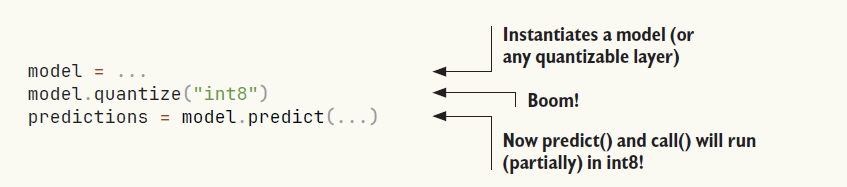

### Chapter summary

You can use hyperparameter tuning and KerasTuner to automate the tedium
out of finding the best model configuration. But be mindful of validation-set
overfitting!

¡ An ensemble of diverse models can often significantly improve the quality of
your predictions.

¡ To further scale your workflows, you can use data parallelism to train a model on
multiple devices, as long as the model is small enough to fit on a single device.

¡ For larger models, you can also use model parallelism to split your model’s variables
and computation across several devices.

¡ You can speed up model training on GPUs or TPUs by turning on mixed precision—
you’ll generally get a nice speed boost at virtually no cost.

¡ You can also speed up inference by using float16 precision or even int8
quantization.